# IMPORTACION DE LIBRERIAS Y CONFIGURACION DE CONSTANTES INICIALES

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


import joblib


DATA_URL = "https://raw.githubusercontent.com/No-Country-simulation/Hackaton_G9_Server_2_Team27/refs/heads/feature/ds-notebooks-modelos/data/processed/dataset_ml_ready_v2.csv"
TARGET = "categoria"
MODEL_OUTPUT_PATH = "modelo_random_forest.joblib"

NUMERIC_FEATURES = ["consumo_kwh", "cantidad_equipos", "horas_alto_consumo"]
BINARY_FEATURES = ["uso_horario_pico"]
CATEGORICAL_FEATURES = ["tipo_inmueble"]


# FUNCIONES MODULARES DE DESARROLLO

In [ ]:

# Carga los datos remotos en crudo para la API.
def cargar_datos_produccion(url: str) -> pd.DataFrame:
    try:
        df = pd.read_csv(url)
        print(f"✅ Datos cargados con éxito. Dimensiones base: {df.shape}")
        return df
    except Exception as e:
        print(f"❌ Error crítico en la carga de datos: {e}")
        raise

def preparar_datos_entrenamiento(df: pd.DataFrame, target_col: str):
    """Separa variables predictoras de la etiqueta y aplica división estratificada."""
    X = df.drop(columns=[target_col])
    y = df[target_col]
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Configura el procesamiento automático de variables y el estimador unificado.
# ColumnTransformer encapsula la codificación y mantiene el orden de columnas fijo
def construir_pipeline_autonomo() -> Pipeline:
    preprocesador = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES),
            ('num', 'passthrough', NUMERIC_FEATURES),
            ('bin', 'passthrough', BINARY_FEATURES)
        ]
    )
    # Inicializa el clasificador con balance de clases automático para perfiles de consumo
    modelo_rf = RandomForestClassifier(
        n_estimators=150, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1
    )
    return Pipeline(steps=[('preprocesador', preprocesador), ('clasificador', modelo_rf)])

#Evalúa métricas, grafica el mapa de calor y serializa el pipeline final.
def evaluar_y_guardar_modelo(pipeline: Pipeline, X_test: pd.DataFrame, y_test: pd.Series, ruta_salida: str) -> None:
    y_pred = pipeline.predict(X_test)

    # Imprime el reporte de métricas en formato texto
    print("\n📊 REPORTE DE RENDIMIENTO DEL MODELO (Conjunto de Prueba Aislado):")
    print(classification_report(y_test, y_pred))

    # Genera la matriz de confusión cuantitativa
    cm = confusion_matrix(y_test, y_pred)

    # Configura e inicializa el mapa de calor visual
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Eficiente', 'Moderado', 'Ineficiente'],
                yticklabels=['Eficiente', 'Moderado', 'Ineficiente'])
    plt.title('Mapa de Calor - Matriz de Confusión')
    plt.ylabel('Clase Real')
    plt.xlabel('Predicción del Modelo')
    plt.show() # Despliega el gráfico directamente en el Jupyter Notebook

    # Serialización comprimida del preprocesador y modelo juntos para OCI
    joblib.dump(pipeline, ruta_salida, compress=3)
    print(f"\n💾 Pipeline unificado serializado con éxito en: '{ruta_salida}'")




# FLUJO DE EJECUCION UNIFICADA / RESULTADOS

🎬 Iniciando proceso de entrenamiento automatizado...
✅ Datos cargados con éxito. Dimensiones base: (9900, 6)
🚀 Entrenando el pipeline unificado...

📊 REPORTE DE RENDIMIENTO DEL MODELO (Conjunto de Prueba Aislado):
              precision    recall  f1-score   support

           0       0.93      0.86      0.90       655
           1       0.80      0.89      0.84       657
           2       0.95      0.91      0.93       668

    accuracy                           0.89      1980
   macro avg       0.89      0.89      0.89      1980
weighted avg       0.89      0.89      0.89      1980



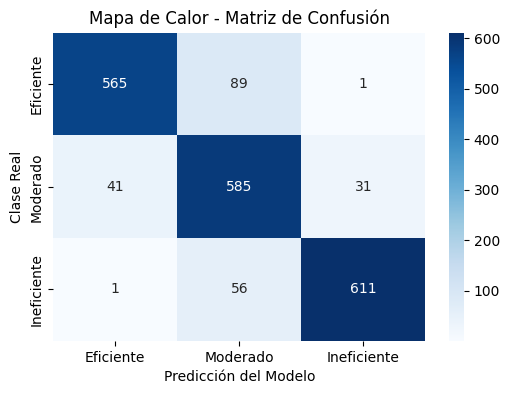


💾 Pipeline unificado serializado con éxito en: 'modelo_random_forest.joblib'
🏁 Proceso finalizado correctamente, Modelo listo para  produccion!!


In [ ]:
print("🎬 Iniciando proceso de entrenamiento automatizado...")

# 1. Ingestión limpia de datos
df_raw = cargar_datos_produccion(DATA_URL)

# Renombrar la columna del dataset para que se alinee con el JSON oficial
df_raw = df_raw.rename(columns={"tipo_vivienda": "tipo_inmueble"})

# 2. Segregación estricta de conjuntos
X_train, X_test, y_train, y_test = preparar_datos_entrenamiento(df_raw, TARGET)

# 3. Inicialización del pipeline
pipeline_produccion = construir_pipeline_autonomo()

# 4. Entrenamiento real del modelo
print("🚀 Entrenando el pipeline unificado...")
pipeline_produccion.fit(X_train, y_train)

# 5. Evaluación final y exportación del archivo .joblib
evaluar_y_guardar_modelo(pipeline_produccion, X_test, y_test, MODEL_OUTPUT_PATH)

print("🏁 Proceso finalizado correctamente, Modelo listo para  produccion!!")


# EVALUACION DEL MODELO Y ANALISIS DE RESULTADOS

### 📊 Evaluación del Modelo y Análisis de Resultados

El modelo predictivo fue entrenado utilizando un pipeline unificado sobre un conjunto de datos de **9,900 registros y 6 características de entrada**, alineándose estrictamente con los requisitos mínimos del MVP exigidos por el Hackathon. La evaluación se realizó sobre un conjunto de prueba aislado y perfectamente balanceado de **1,980 muestras** (~660 observaciones por clase).

---

#### 📈 Desempeño Global (Classification Report)

El clasificador alcanzó una **precisión general (Accuracy) del 89%**, demostrando una alta robustez y capacidad de generalización para determinar el perfil energético residencial.

*   **Eficiente (Clase 0):** Consigue un **F1-score de 0.90** (Precision: 0.93 / Recall: 0.86), identificando con éxito a los usuarios con hábitos óptimos de consumo.
*   **Moderado (Clase 1):** Registra el desempeño más bajo con un **F1-score de 0.84** (Precision: 0.80 / Recall: 0.89). Este comportamiento es esperado debido al solapamiento natural en las fronteras de consumo cuantitativo.
*   **Ineficiente (Clase 2):** Obtiene el rendimiento más destacado con un **F1-score de 0.93** y una **precisión del 95%**. Esto garantiza que el sistema detecte con máxima fiabilidad los casos de alto desperdicio energético.

---

#### 🧩 Análisis de la Matriz de Confusión

La matriz de confusión ratifica visualmente la solidez del modelo mediante una diagonal principal densa y un comportamiento lógico de los errores:

1.  **Separación de Extremos Exitosa:** El riesgo de cometer errores críticos es prácticamente nulo. Solo **1 caso real eficiente** fue etiquetado como ineficiente, y **1 caso real ineficiente** fue clasificado como eficiente. Esto valida la seguridad del modelo para el usuario final.
2.  **Solapamiento en Zonas de Transición:** Las falsas clasificaciones se concentran exclusivamente en los límites adyacentes de la clase *Moderado* (89 casos eficientes y 56 ineficientes se predijeron como moderados). Esto refleja la continuidad matemática de la variable de consumo en kWh.

**Conclusión para el MVP:** El modelo cumple con los criterios de aceptación y está listo para su integración con la API REST en Spring Boot y su posterior despliegue en la infraestructura de Oracle Cloud Infrastructure (OCI).
